# I. Project Team Members

| Prepared by | Email | Prepared for |
| :-: | :-: | :-: |
| **Hardefa Rogonondo** | hardefarogonondo@gmail.com | **Kumparan Topic Extractor Engine** |

# II. Notebook Target Definition

This notebook documents the Model Training and Evaluation phase for the Kumparan Topic Extractor Engine, executing a rigorous comparative analysis to identify the optimal classification architecture. Utilizing the preprocessed dataset, we first standardize the features and establish a performance baseline using a Dummy Classifier that predicts the majority class. The primary modeling workflow constructs a pipeline combining a TF-IDF Vectorizer with a LinearSVC, optimizing its performance through hyperparameter tuning with GridSearchCV. We further evaluate a challenger model using Logistic Regression and develop a voting ensemble model that fuses the LinearSVC and Logistic Regression predictions. The notebook concludes by comparing metrics across all candidates, selecting the best-performing model, and exporting the final artifacts and evaluation report for deployment.

# III. Notebook Setup

## III.A. Import Libraries

In [1]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import re
import seaborn as sns
import string
import time

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## III.B. Import Data

In [2]:
df_train = pd.read_pickle('../../data/processed/df_train.pkl')
df_test = pd.read_pickle('../../data/processed/df_test.pkl')

In [3]:
df_train.head()

,article_id,article_topic,article_content,word_count
4931,93191138,Hiburan,"Beberapa waktu lalu, kakak dari Caisar Putra ...",295
3644,93185507,Sepak Bola,Kontributor : Muhammad QomarudinblokBojonegor...,330
6399,93231570,Pilgub Jatim,"SURABAYA, BANGSAONLINE.com - DPD Partai Golka...",249
3748,93210106,Sains,Untuk pertama kalinya hal ini dilakukanPeneli...,142
2656,93204737,Haji,Madinah (MCH) - Cuaca di Madinah cukup ekstr...,381


In [4]:
df_test.head()

,article_id,article_topic,article_content,word_count
3776,93224871,Hiburan,Baru-baru ini musisi sekaligus anggota DPR RI...,314
8467,93231867,Ekonomi,Presiden Joko Widodo biasa membuat vlog saat ...,296
5553,93187636,Ekonomi,Kementerian Agraria dan Tata Ruang/Badan Pert...,191
5556,93234070,Hiburan,Mendiang Benny Panjaitan alias Benny 'Panbers...,270
4319,93190248,Haji,MCH -- Menjelang pelaksanaan puncak haji 143...,245


# IV. Models Training and Evaluation

## IV.A. Data Shape Inspection

In [5]:
df_train.shape, df_test.shape

((6929, 4), (2970, 4))

## IV.B. Data Information Inspection

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6929 entries, 4931 to 1953
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   article_id       6929 non-null   int64 
 1   article_topic    6929 non-null   object
 2   article_content  6929 non-null   object
 3   word_count       6929 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 270.7+ KB


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2970 entries, 3776 to 2682
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   article_id       2970 non-null   int64 
 1   article_topic    2970 non-null   object
 2   article_content  2970 non-null   object
 3   word_count       2970 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 116.0+ KB


## IV.C. Standardization

In [8]:
def standardization(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = " ".join(text.split())
    return text

In [9]:
X_train = df_train["article_content"].apply(standardization)
y_train = df_train["article_topic"]
X_test = df_test["article_content"].apply(standardization)
y_test = df_test["article_topic"]
print(f"Example uncleaned text:\n{df_train['article_content'].iloc[0][:100]}...")
print(f"Example clean text:\n{X_train.iloc[0][:100]}...")

Example uncleaned text:
 Beberapa waktu lalu, kakak dari Caisar Putra Aditya alias Caisar 'YKS', Dermawan alias Wawan, perna...
Example clean text:
beberapa waktu lalu kakak dari caisar putra aditya alias caisar yks dermawan alias wawan pernah meng...


In [10]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name="Model", plot_cm=False):
    print(f"Training {model_name}")
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    duration = end_time - start_time
    print(f"Training completed in: {duration:.2f} seconds")
    if duration < 1800:
        print("✅ Time Limit Passed")
    else:
        print("❌ WARNING: Training took too long!")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    if plot_cm:
        classes = model.classes_
        cm = confusion_matrix(y_test, y_pred, labels=classes)
        sns.heatmap(cm, annot=False, fmt='d', xticklabels=classes, yticklabels=classes, cmap='viridis')
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.title(f"Confusion Matrix: {model_name}")
        plt.show()
    return {
        "model_name": model_name,
        "model": model,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "duration": duration
    }

In [11]:
results_list = []

## IV.D. Benchmark Model Performance Review

In [12]:
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
dummy_pred = dummy_clf.predict(X_test)
dummy_acc = accuracy_score(y_test, dummy_pred)
dummy_time = 0.1 # Negligible
results_list.append({
    "model_name": "Dummy Model",
    "model": dummy_clf,
    "accuracy": dummy_acc,
    "macro_f1": f1_score(y_test, dummy_pred, average='macro'),
    "duration": dummy_time
})

## IV.E. Main Model

Training LinearSVC
Training completed in: 5.84 seconds
✅ Time Limit Passed
Accuracy: 0.8886

Classification Report:
               precision    recall  f1-score   support

       Bisnis       0.33      0.14      0.20         7
   Bojonegoro       0.96      0.95      0.95        78
      Ekonomi       0.95      0.94      0.95       528
         Haji       0.99      0.98      0.98       445
       Health       0.49      0.54      0.51        39
      Hiburan       0.94      0.95      0.94       428
        Horor       0.82      0.60      0.69        15
        Hukum       0.62      0.72      0.67        25
Internasional       0.89      0.92      0.90       222
      Jakarta       1.00      0.50      0.67         4
        K-Pop       0.85      1.00      0.92        17
          KPK       1.00      0.55      0.71        11
    Kesehatan       0.66      0.61      0.64        57
     Keuangan       1.00      0.25      0.40         4
    Lifestyle       0.85      0.89      0.87       170
   

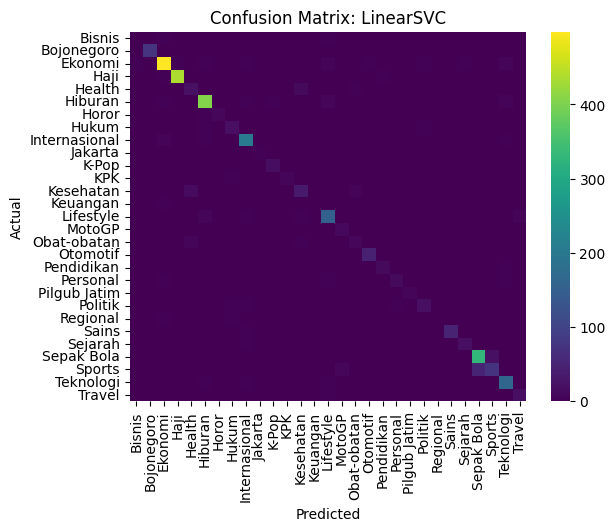

In [13]:
pipeline_svc = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', LinearSVC(class_weight='balanced', random_state=777))
])
metrics_svc = train_and_evaluate(pipeline_svc, X_train, y_train, X_test, y_test, "LinearSVC", plot_cm=True)
results_list.append(metrics_svc)

## IV.F. Hyperparameters Tuning

In [14]:
# Small C = More regularization (simpler model, less overfitting).
# Large C = Less regularization (tries to fit every point).
svc_params = {
    "clf__C": [0.1, 0.5, 1, 5, 10],
    "clf__loss": ['squared_hinge'], # Standard for LinearSVC
    "clf__class_weight": ["balanced", None]
}

In [15]:
svc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', LinearSVC(random_state=777))
])
grid_svc = GridSearchCV(svc_pipeline, svc_params, cv=5, scoring='f1_macro', n_jobs=-1)
trained_grid = train_and_evaluate(grid_svc, X_train, y_train, X_test, y_test, "GridSearch SVC")
print(f"Best SVC Params: {trained_grid['model'].best_params_}")
print(f"Best SVC CV Score: {trained_grid['model'].best_score_:.4f}")

Training GridSearch SVC
Training completed in: 74.88 seconds
✅ Time Limit Passed
Accuracy: 0.8886

Classification Report:
               precision    recall  f1-score   support

       Bisnis       0.33      0.14      0.20         7
   Bojonegoro       0.96      0.95      0.95        78
      Ekonomi       0.95      0.94      0.95       528
         Haji       0.99      0.98      0.98       445
       Health       0.49      0.54      0.51        39
      Hiburan       0.94      0.95      0.94       428
        Horor       0.82      0.60      0.69        15
        Hukum       0.62      0.72      0.67        25
Internasional       0.89      0.92      0.90       222
      Jakarta       1.00      0.50      0.67         4
        K-Pop       0.85      1.00      0.92        17
          KPK       1.00      0.55      0.71        11
    Kesehatan       0.66      0.61      0.64        57
     Keuangan       1.00      0.25      0.40         4
    Lifestyle       0.85      0.89      0.87       1

## IV.G. Challenger Model

In [16]:
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=777))
])
metrics_lr = train_and_evaluate(pipeline_lr, X_train, y_train, X_test, y_test, "Logistic Regression")
results_list.append(metrics_lr)

Training Logistic Regression
Training completed in: 6.21 seconds
✅ Time Limit Passed
Accuracy: 0.8747

Classification Report:
               precision    recall  f1-score   support

       Bisnis       1.00      0.14      0.25         7
   Bojonegoro       0.99      0.91      0.95        78
      Ekonomi       0.93      0.94      0.93       528
         Haji       0.99      0.97      0.98       445
       Health       0.50      0.54      0.52        39
      Hiburan       0.92      0.95      0.94       428
        Horor       1.00      0.60      0.75        15
        Hukum       0.67      0.72      0.69        25
Internasional       0.87      0.90      0.89       222
      Jakarta       1.00      0.50      0.67         4
        K-Pop       0.89      1.00      0.94        17
          KPK       1.00      0.55      0.71        11
    Kesehatan       0.66      0.58      0.62        57
     Keuangan       0.25      0.25      0.25         4
    Lifestyle       0.87      0.86      0.87    

## IV.H. Ensemble Model

In [17]:
svc = LinearSVC(class_weight='balanced', random_state=777)
calibrated_svc = CalibratedClassifierCV(svc, method='sigmoid', cv=5)
lr = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=777)
pipeline_ensemble = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('voting', VotingClassifier(
        estimators=[('svc', calibrated_svc), ('lr', lr)],
        voting='soft'
    ))
])
metrics_ensemble = train_and_evaluate(pipeline_ensemble, X_train, y_train, X_test, y_test, "Ensemble Model")
results_list.append(metrics_ensemble)

Training Ensemble Model
Training completed in: 10.69 seconds
✅ Time Limit Passed
Accuracy: 0.8902

Classification Report:
               precision    recall  f1-score   support

       Bisnis       1.00      0.14      0.25         7
   Bojonegoro       0.97      0.92      0.95        78
      Ekonomi       0.94      0.95      0.94       528
         Haji       0.99      0.98      0.99       445
       Health       0.46      0.46      0.46        39
      Hiburan       0.92      0.96      0.94       428
        Horor       0.82      0.60      0.69        15
        Hukum       0.67      0.72      0.69        25
Internasional       0.88      0.93      0.91       222
      Jakarta       1.00      0.50      0.67         4
        K-Pop       0.94      0.94      0.94        17
          KPK       1.00      0.55      0.71        11
    Kesehatan       0.71      0.63      0.67        57
     Keuangan       1.00      0.25      0.40         4
    Lifestyle       0.83      0.88      0.85       1

## IV.I. Models Comparison

In [18]:
df_results = pd.DataFrame(results_list)
display_df = df_results.drop(columns=["model"])
display_df

,model_name,accuracy,macro_f1,duration
0,Dummy Model,0.177778,0.010410,0.100000
1,LinearSVC,0.888552,0.723939,5.838171
2,Logistic Regression,0.874747,0.710503,6.214108
3,Ensemble Model,0.890236,0.724835,10.690411


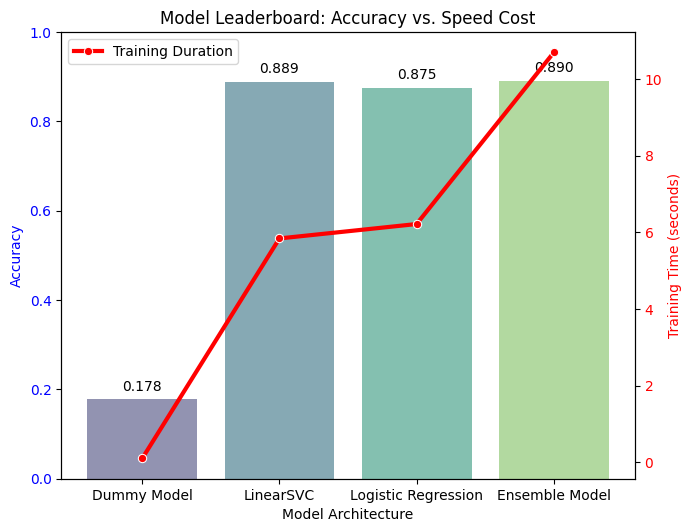

In [19]:
fig, ax1 = plt.subplots(figsize=(7.4, 5.8))
sns.barplot(
    data=df_results,
    x="model_name",
    y="accuracy",
    hue="model_name",
    legend=False,
    alpha=0.6,
    palette='viridis',
    ax=ax1
)
ax1.set_ylabel("Accuracy", color='blue')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel("Model Architecture")
ax2 = ax1.twinx()
sns.lineplot(
    data=df_results,
    x="model_name",
    y="duration",
    marker='o',
    color='red',
    ax=ax2,
    linewidth=3,
    label="Training Duration"
)
ax2.set_ylabel("Training Time (seconds)", color='red')
ax2.tick_params(axis='y', labelcolor='red')
for index, row in df_results.iterrows():
    ax1.text(index, row["accuracy"] + 0.02, f"{row['accuracy']:.3f}", color='black', ha='center')
plt.title("Model Leaderboard: Accuracy vs. Speed Cost")
plt.show()

In [20]:
best_model = metrics_ensemble["model"]

## IV.J. Model Analysis

In [21]:
voting_clf = best_model.named_steps["voting"]
original_classes = voting_clf.classes_
ensemble_logreg = voting_clf.estimators_[1]
feature_names = best_model.named_steps["tfidf"].get_feature_names_out()

In [22]:
def print_top_keywords_fixed(original_classes, inner_model, feature_names, n_top=10):
    print("Top Keywords Driving the Ensemble Model")
    for i, class_label in enumerate(original_classes):
        if class_label in ["Ekonomi", "Bisnis", "Sepak Bola", "Haji", "Teknologi"]:
            if hasattr(inner_model, "coef_"):
                top_indices = np.argsort(inner_model.coef_[i])[-n_top:]
                top_keywords = [feature_names[j] for j in top_indices]
                print(f"Topic: {class_label}")
                print(f"  Keywords: {', '.join(top_keywords)}")
                print("-" * 30)

In [23]:
print_top_keywords_fixed(original_classes, ensemble_logreg, feature_names)

Top Keywords Driving the Ensemble Model
Topic: Bisnis
  Keywords: pengiriman, toko, produk, beliau, yang, anda, sapi, usaha, harga, bisnis
------------------------------
Topic: Ekonomi
  Keywords: sebesar, keuangan, pemerintah, tol, kementerian, pt, pajak, saham, rp, bank
------------------------------
Topic: Haji
  Keywords: embarkasi, jemaah haji, saudi, makkah, mch, madinah, kloter, jamaah, jemaah, haji
------------------------------
Topic: Sepak Bola
  Keywords: pertandingan, bola, pssi, pelatih, neymar, gol, musim, timnas, laga, pemain
------------------------------
Topic: Teknologi
  Keywords: perusahaan, teknologi, iphone, startup, fitur, google, aplikasi, pengguna, game, ponsel
------------------------------


## IV.K. Export Reports

In [24]:
display_df.to_csv('../../reports/model_leaderboard.csv', index=False)

## IV.L. Export Model

In [25]:
with open('../../models/best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)